In [ ]:
#IMPORTANDO LIBRERIAS A USAR
#LEYENDO BASE DE DATOS
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df=pd.read_csv(r"C:\Users\jcuad\OneDrive\Documents\PORTAFOLIO DE PROYECTOS\DATA\Sample - Superstore.csv",encoding='latin1')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [79]:
#CREANDO NUEVAS COLUMNAS DE DIA DE LA SEMANA, MES Y AÑO
df['Dia_Semana']=pd.to_datetime(df['Order Date']).dt.day_name()
df['Mes']=pd.to_datetime(df['Order Date']).dt.month_name()
df['Año']=pd.to_datetime(df['Order Date']).dt.year
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Dia_Semana,Mes,Año
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Tuesday,November,2016
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Tuesday,November,2016
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Sunday,June,2016
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,Sunday,October,2015
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Sunday,October,2015


Dia_Semana
Friday       427692.2593
Monday       428937.8157
Saturday     357984.6830
Sunday       385353.8464
Thursday     321965.7785
Tuesday      287209.5022
Wednesday     88056.9752
Name: Sales, dtype: float64


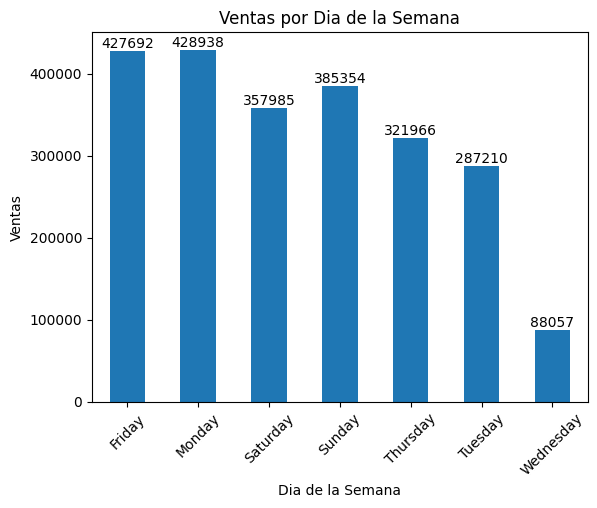

In [ ]:
#ANALISIS DE VENTAS POR DIA DE LA SEMANA
ventas_dia_semana=df.groupby('Dia_Semana')['Sales'].sum()
print(ventas_dia_semana)
#GRAFICO DE VENTAS POR DIA DE LA SEMANA
ax = ventas_dia_semana.plot(kind='bar')
plt.title('Ventas por Dia de la Semana')
plt.xlabel('Dia de la Semana')
plt.ylabel('Ventas')
plt.xticks(rotation=45)

# Agregar etiquetas a las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()



In [ ]:
##ANALIZANDO VENTAS DE MONDAY(LUNES)
ventas_dia_lunes=df[df['Dia_Semana'] =="Monday"]
ventas_dia_lunes_categorias=ventas_dia_lunes.groupby('Category')[['Sales','Profit']].sum().assign(Margen_pct= lambda x:(x['Profit']/x['Sales'])*100).round(2).sort_values(by='Margen_pct',ascending=False)
ventas_dia_lunes_categorias

,Sales,Profit,Margen_pct
Category,,,
Office Supplies,136498.70,30576.24,22.40
Technology,132612.51,16286.79,12.28
Furniture,159826.60,4648.08,2.91


In [ ]:
##ANALIZANDO VENTAS DE MONDAY(LUNES) - CATEGORIA:FURNITURE(MUEBLES)
ventas_furniture_lunes=ventas_dia_lunes[ventas_dia_lunes['Category']=='Furniture'].groupby('Sub-Category')[['Sales','Profit']].sum().assign(Margen_pct= lambda x:(x['Profit']/x['Sales'])*100).round(2).sort_values(by='Margen_pct',ascending=False)
ventas_furniture_lunes

,Sales,Profit,Margen_pct
Sub-Category,,,
Furnishings,14037.00,2594.46,18.48
Chairs,73070.36,5755.53,7.88
Bookcases,19097.16,-277.88,-1.46
Tables,53622.09,-3424.04,-6.39


In [118]:
##ANALIZANDO VENTAS DE MONDAY(LUNES) - CATEGORIA:FURNITURE(MUEBLES) - SUBCATEGORIA:TABLES(MESAS)
ventas_fur_tables_lunes=ventas_dia_lunes[(ventas_dia_lunes['Category']=='Furniture') & (ventas_dia_lunes['Sub-Category']=='Tables')]
ventas_fur_tables_lunes=ventas_fur_tables_lunes.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'}).assign(Margen_pct= lambda x:(x['Profit']/x['Sales'])*100).round(2).sort_values(by='Margen_pct',ascending=False)
ventas_fur_tables_lunes

,Sales,Profit,Discount,Margen_pct
Region,,,,
West,22828.27,1840.16,0.16,8.06
South,15663.00,-1835.85,0.21,-11.72
Central,7763.97,-1342.24,0.28,-17.29
East,7366.85,-2086.10,0.38,-28.32


Punto de Equilibrio (Descuento Máximo): 17.53%


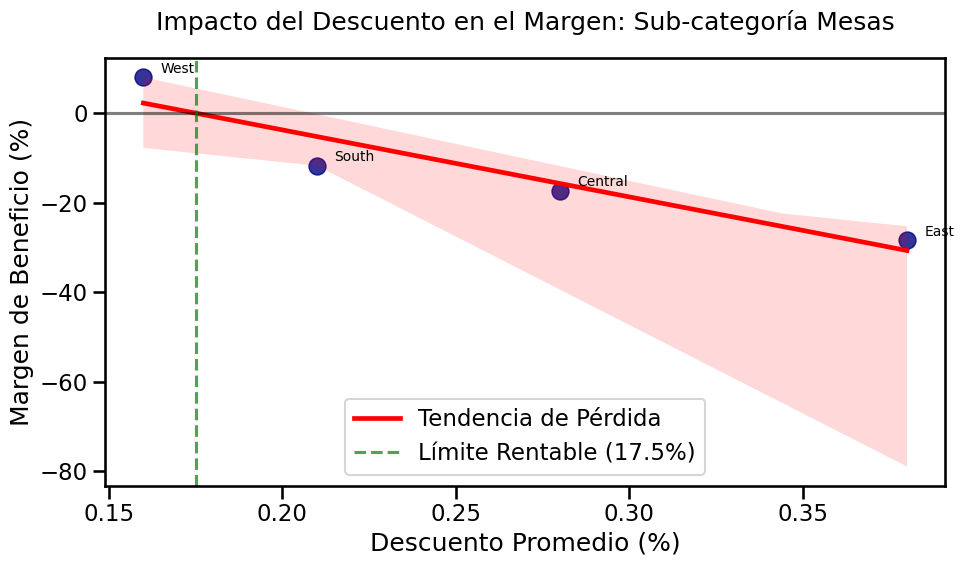

--- ANÁLISIS DE COMPORTAMIENTO ESTÁNDAR ---
1. Pendiente (m): -149.86
2. Intersección (b): 26.27%
----------------------------------------
Interpretación: Por cada 1% que aumentamos el descuento,
el margen de beneficio se reduce un 1.50%.


In [128]:
#RESETEMAOS EL DATAFRAME PARA PODER PROCEDER CON LA REGRESION LINEAL
# Solo reseteamos si 'Region' NO está en las columnas (así evitamos el error al re-ejecutar)
if 'Region' not in ventas_fur_tables_lunes.columns:
    ventas_fur_tables_lunes = ventas_fur_tables_lunes.reset_index()
# Calculamos la regresión (polinomio de grado 1 = línea recta)
# y = mx + b
coefficients = np.polyfit(ventas_fur_tables_lunes['Discount'], ventas_fur_tables_lunes['Margen_pct'], 1)
m, b = coefficients
breakeven_discount = -b / m
print(f"Punto de Equilibrio (Descuento Máximo): {breakeven_discount:.2%}")

# 3. Visualización Profesional
plt.figure(figsize=(10, 6))
sns.set_context("talk")

# Línea de tendencia y puntos
sns.regplot(x='Discount', y='Margen_pct', data=ventas_fur_tables_lunes, 
            scatter_kws={'s':150, 'color':'navy'}, 
            line_kws={'color':'red', 'label':'Tendencia de Pérdida'})

# Estética del gráfico
plt.axhline(0, color='black', linestyle='-', alpha=0.5) # Línea de Profit 0
plt.axvline(breakeven_discount, color='green', linestyle='--', alpha=0.7, 
            label=f'Límite Rentable ({breakeven_discount:.1%})')

# Etiquetas de Región
for i in range(len(ventas_fur_tables_lunes)):
    # .iloc[i] garantiza que tomamos la fila por posición física (0, 1, 2...)
    x_val = ventas_fur_tables_lunes['Discount'].iloc[i]
    y_val = ventas_fur_tables_lunes['Margen_pct'].iloc[i]
    region_name = ventas_fur_tables_lunes['Region'].iloc[i]
    
    plt.text(x_val + 0.005, y_val + 1, region_name, fontsize=10)

plt.title('Impacto del Descuento en el Margen: Sub-categoría Mesas', pad=20)
plt.xlabel('Descuento Promedio (%)')
plt.ylabel('Margen de Beneficio (%)')
plt.legend()
plt.tight_layout()

plt.savefig('sensibilidad_descuento_mesas.png')
plt.show()
print("--- ANÁLISIS DE COMPORTAMIENTO ESTÁNDAR ---")
print(f"1. Pendiente (m): {m:.2f}")
print(f"2. Intersección (b): {b:.2f}%")
print("-" * 40)

impacto_1_pct = abs(m * 0.01)
print(f"Interpretación: Por cada 1% que aumentamos el descuento,")
print(f"el margen de beneficio se reduce un {impacto_1_pct:.2f}%.")